# Resonance Absorption

In this notebook, we build directly on the simple model defined in the last lesson.

In [1]:
import openmc
import numpy as np
import matplotlib.pyplot as plt

model = openmc.Model()

We'll start by creating an OpenMC model for a mixture of natural uranium and water defined by the ratio of H to U atoms.

## Step 1: Materials

Let's define a homogeneous mixture of water with natural uranium.

In [2]:
H_to_U = 100 # Hydrogen to Uranium ratio
N_H = 2
N_O = 1
N_U = N_H/H_to_U 
water = openmc.Material(name="uranium water")
water.add_nuclide("H1",  N_H)
water.add_nuclide("O16", N_O)
water.add_element("U",   N_U)
water.set_density("g/cm3", 1.0)
water.temperature = 294
model.materials = openmc.Materials([water])

## Step 2: Geometry

It is not generally feasible to model an infinite domain explicitly.  Rather, we can model a finite region of space with an outer, **reflective** surface.  Here, the simplest way to do that is to create a sphere centered at the origin that is filled with our moderating material.  First, define the sphere:  

In [3]:
sphere = openmc.Sphere(r=1.0, boundary_type="reflective") 

The radius selected is arbitrary since the reflective boundary effectively makes this an infinite domain.

Next, we define a cell whose region of space is everything inside the sphere (`-sphere`) and whose fill material is water:

In [4]:
moderator_cell = openmc.Cell()
moderator_cell.region = -sphere
moderator_cell.fill = water

Finally, all of the cells of a model must live inside a universe, and there must be at least one "root" universe in each geometry.  Here, we only need the root universe and assign the cell to it as follows:

In [5]:
root_universe = openmc.Universe(cells=(moderator_cell,))
model.geometry.root_universe = root_universe

## Step 3: Settings

In [6]:
settings = openmc.Settings()
space_distn = openmc.stats.Point((0, 0, 0))
energy_distn = openmc.stats.Discrete([1e6], [1.0])
source = openmc.IndependentSource(space=space_distn, energy=energy_distn)
settings.source = source
settings.batches = 100
settings.particles = 1000
settings.run_mode = "fixed source"
settings.cutoff = {"energy_neutron": 1.0}
model.settings = settings

## Step 4: Tallies

In [7]:
energies = np.logspace(np.log10(1.0), np.log10(0.1e6), 10000)
e_filter = openmc.EnergyFilter(energies)
tally = openmc.Tally()
tally.filters = [e_filter]
tally.scores = ['flux']
model.tallies = [tally]

## Step 5: Run OpenMC

In [8]:
sp_path = model.run(output=False)

## Step 6: Postprocess Results

In [9]:
with openmc.StatePoint(sp_path) as sp:
    t = sp.tallies[tally.id]
    flux_mean = t.mean.ravel()*100*1000*(4/3*np.pi)
    flux_unc = t.std_dev.ravel()*100*1000*(4/3*np.pi)
phi_openmc = flux_mean/np.diff(energies)

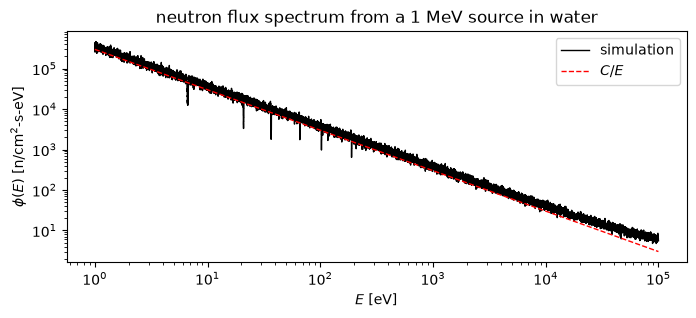

In [10]:
plt.figure(figsize=(8,3))
plt.step(energies[:-1], phi_openmc, color='k', lw=1, label="simulation")
plt.plot(energies[:-1], 3e5/energies[:-1], 'r--', lw=1, label="$C/E$")
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$E$ [eV]')
plt.ylabel(r'$\phi(E)$ [n/cm$^2$-s-eV]');
plt.legend()
plt.title("neutron flux spectrum from a 1 MeV source in water");

## Step 7: Compare to the NR Approximation

In [11]:
N = water.get_nuclide_atom_densities()  # atom/b-cm
library = openmc.data.DataLibrary.from_xml()
xs = {n: openmc.data.IncidentNeutron.from_hdf5(library.get_by_material(n)["path"])
      for n in N}

In [12]:
E = energies[:-1]
T = f"{water.temperature:.0f}K"
Sigma_s = sum(N[n] * xs[n][2].xs[T](E) for n in ("H1", "O16"))
Sigma_t = sum(N[n] * xs[n][1].xs[T](E) for n in N)  # cm^-1

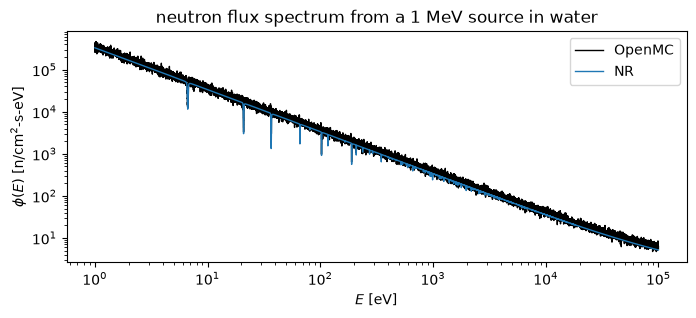

In [13]:
C = 4e5 # scale to match

phi_NR = C/(Sigma_t*E)
fig, ax = plt.subplots(figsize=(8, 3))
ax.step(energies[:-1],phi_openmc, where='post', color='k', lw=1, label="OpenMC")
ax.plot(E, phi_NR, lw=1, label=r"NR")

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('$E$ [eV]')
ax.set_ylabel(r'$\phi(E)$ [n/cm$^2$-s-eV]')
ax.legend()
ax.set_title("neutron flux spectrum from a 1 MeV source in water");

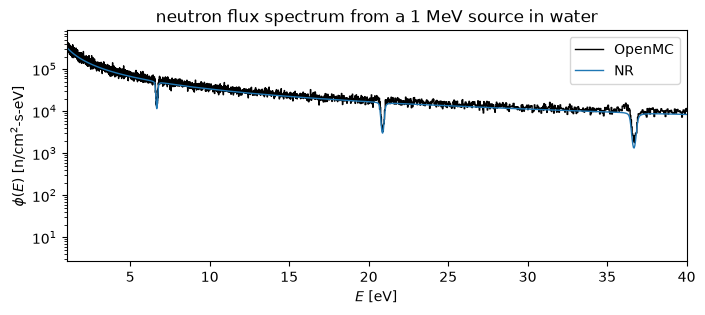

In [14]:
# Zoom in
ax.set_xlim(1, 40)
ax.set_xscale("linear")
fig